# Netflix Dataset analysis
<h2><b>Task-2</b> Content Type Analysis Dashboard</h2>
<h3><b>Description :</b>  Analyze the distribution of Movies and TV Shows available on Netflix </h3>
<h4><b>Step 1:</b>Load the cleaned dataset.</h4>

In [1]:
import numpy as mp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv("Netflix_Cleaned_Dataset.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
df.shape

(8790, 10)

<h4>
    <b>Step 2:</b>Calculate the total number of Movies and TV Shows.<br>
    <b>Step 3:</b> Create visualizations for content distribution.<br>
    <b>Step 4:</b> Compare content proportions.<br>
    <b>Step 5:</b> Summarize key findings.<br>
</h4>

In [4]:
df['type'].unique()

<ArrowStringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [5]:
content_count =df['type'].value_counts()
print(content_count)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [6]:
content_count_percentage = (df['type'].value_counts(normalize=True)*100).round(2)
print(content_count_percentage)

type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


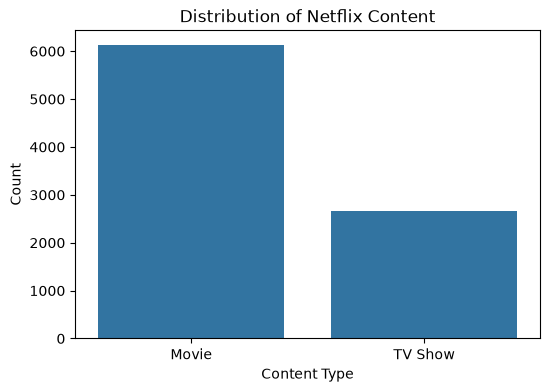

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(df,x='type')
plt.title("Distribution of Netflix Content")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

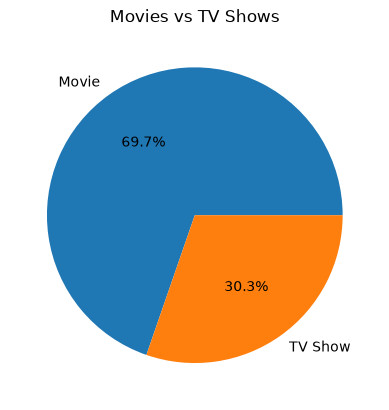

In [8]:
content_count.plot(kind='pie',autopct='%1.1f%%',ylabel='')
plt.title("Movies vs TV Shows")
plt.show()

<h5><b>Business insights or Key findings</b><br>
    <b>--></b>Netflix catalog contains more Movies than TV Shows means (Movies >> TV Shows).<br>
    <b>--></b>Movies represent the majority of the platform's content consumption.<br>
    <b>--></b>TV Shows occupy a smaller share of the catalog.<br>
    <b>--></b>Almost 70 percent of the peoples wants to see the Movies on Netflix rather then TV Shows so we can more release the Movies.<br>
    <b>--></b>Almost 30 percent of the peoples wants to see the TV Shows on Netflix rather then Movies so we can less release the TV Shows.<br><br>
</h5>

# Netflix Dataset analysis
<h2><b>Task 3 (Medium) –</b>Country-Wise Netflix Content Analysis</h2>
<h3><b>Description :</b>  Analyze Netflix content availability across different countries. </h3>
<h4><b>Step 1:</b>Extract and clean country information.</h4>

In [9]:
df['country'].sample(10, random_state=42)

3942           Canada
8360      South Korea
221          Pakistan
4883            Egypt
2210    United States
3527           France
1075        Indonesia
4469            India
8525         Pakistan
2926           Mexico
Name: country, dtype: str

In [10]:
df['country'].str.contains(',').sum()

np.int64(0)

<h4>
    <b>Step 2:</b>Calculate content count by country.<br>
</h4>

In [11]:
country_analysis = df[df['country'] != 'Unknown']
country_count =(df['country'].value_counts().reset_index())
country_count.columns=['Country','Content Count']
country_count.head(10)

,Country,Content Count
0,United States,3240
1,India,1057
2,United Kingdom,638
3,Pakistan,421
4,Unknown,287
5,Canada,271
6,Japan,259
7,South Korea,214
8,France,213
9,Spain,182


In [12]:
top10 = country_count.head(10)
top10

,Country,Content Count
0,United States,3240
1,India,1057
2,United Kingdom,638
3,Pakistan,421
4,Unknown,287
5,Canada,271
6,Japan,259
7,South Korea,214
8,France,213
9,Spain,182


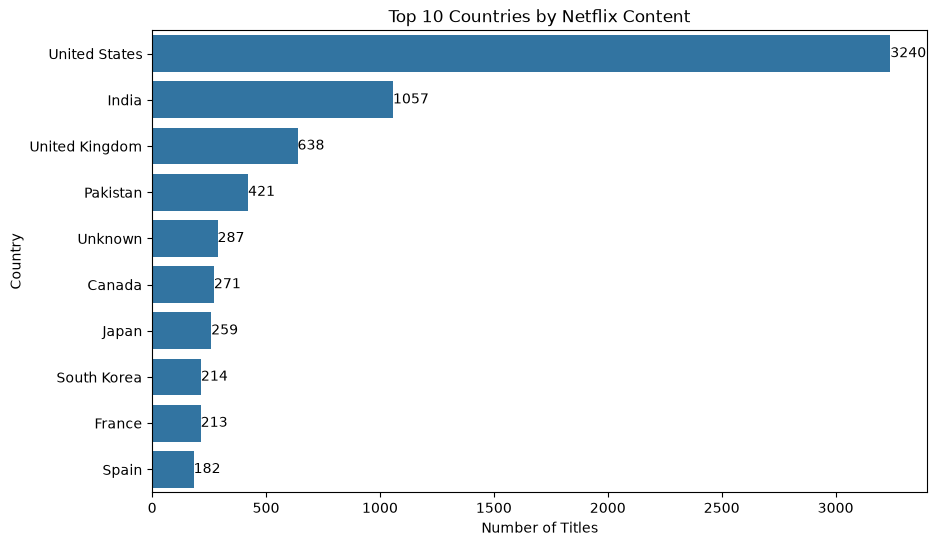

In [13]:
plt.figure(figsize=(10,6))
datas= sns.barplot(data=top10,x='Content Count',y='Country')
for i in datas.containers:
    datas.bar_label(i)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

<h4>
    <b>Step 3:</b> Identify top content-producing countries.<br>
    <b>Step 4:</b> Create charts and rankings.<br>
    <b>Step 5:</b> Generate business insights.<br>
</h4>

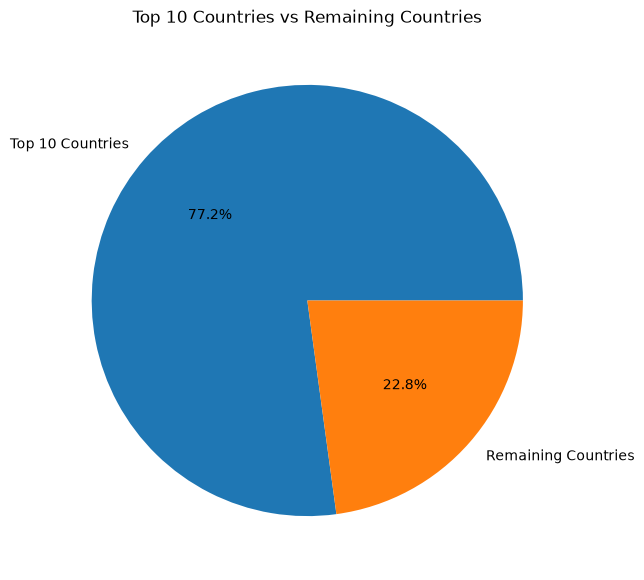

In [14]:
plt.figure(figsize=(7,7))
plt.pie([country_count.head(10)['Content Count'].sum(),country_count.iloc[10:]['Content Count'].sum()],labels=['Top 10 Countries', 'Remaining Countries'],autopct='%1.1f%%')
plt.title("Top 10 Countries vs Remaining Countries")
plt.show()

<h5><b>Business insights or Key findings</b><br>
    <b>--></b>United States has the highest number of Netflix titles which is = 3204.<br>
    <b>--></b>India ranks second with a significant contribution = 1057.<br>
    <b>--></b>The top 10 countries contribute the majority of Netflix's available content which is aorund 77.2% of the entire Netflix's total content share.<br>
    <b>--></b>The remaining countries contribute only 22.8%, showing a comparatively lower share of the Netflix's total Content share.<br>
</h5>

# Netflix Dataset analysis
<h2><b>Task 4 (Medium) –</b>Trend Analysis by Release Year</h2>
<h3><b>Description :</b>  Analyze how Netflix content production has changed over time.</h3>
<h4><b>Step 1:</b>Organize content by release year.</h4>

In [15]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [16]:
df['release_year'].dtype

dtype('int64')

In [17]:
print(df['release_year'].min())
print(df['release_year'].max())

1925
2021


In [18]:
df['release_year'].head(10)

0    2020
1    2021
2    2021
3    2021
4    1993
5    2021
6    2021
7    2019
8    2021
9    2013
Name: release_year, dtype: int64

<h5>The release_year column contains no missing values and is stored as an integer datatype. The release years range from 1925 to 2021</h5>

<h4><b>Step 2:</b>Calculate yearly content releases.</h4>

In [19]:
yearly_content = (df.groupby('release_year').size().reset_index(name='Content Count'))

In [20]:
yearly_content.head()

,release_year,Content Count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


In [21]:
yearly_content.tail()

,release_year,Content Count
69,2017,1030
70,2018,1146
71,2019,1030
72,2020,953
73,2021,592


<h4><b>Step 3:</b>Identify growth and decline trends.</h4>

In [22]:
yearly_content['growth in percentage']=(yearly_content['Content Count'].pct_change()*100).round(2)

In [23]:
yearly_content.tail(10)

,release_year,Content Count,growth in percentage
64,2012,236,27.57
65,2013,286,21.19
66,2014,352,23.08
67,2015,555,57.67
68,2016,901,62.34
69,2017,1030,14.32
70,2018,1146,11.26
71,2019,1030,-10.12
72,2020,953,-7.48
73,2021,592,-37.88


In [28]:
yearly_content['Change'] = yearly_content['Content Count'].diff()

In [24]:
yearly_content.loc[yearly_content['Content Count'].idxmax()]

release_year            2018.00
Content Count           1146.00
growth in percentage      11.26
Name: 70, dtype: float64

<h5>Highest Production Year</h5>

In [29]:
yearly_content.loc[yearly_content['Change'].idxmax()]

release_year            2016.00
Content Count            901.00
growth in percentage      62.34
Change                   346.00
Name: 68, dtype: float64

<h5>Largest Year-over-Year Increase</h5>

In [30]:
yearly_content.loc[yearly_content['Change'].idxmin()]

release_year            2021.00
Content Count            592.00
growth in percentage     -37.88
Change                  -361.00
Name: 73, dtype: float64

<h5>Largest Year-over-Year Decline</h5>

<h5>Content production increased in mid-2010s, with the largest year-over-year increase occurring in 2016 (+62.34%). 
    <br>The catalog reached its highest recorded production in 2018 with 1,146 titles. 
    <br>A decline is observed after 2018, with the largest decrease occurring in 2021 (-37.88%)</h5>

<h4><b>Step 4:</b>Create trend visualizations.</h4>

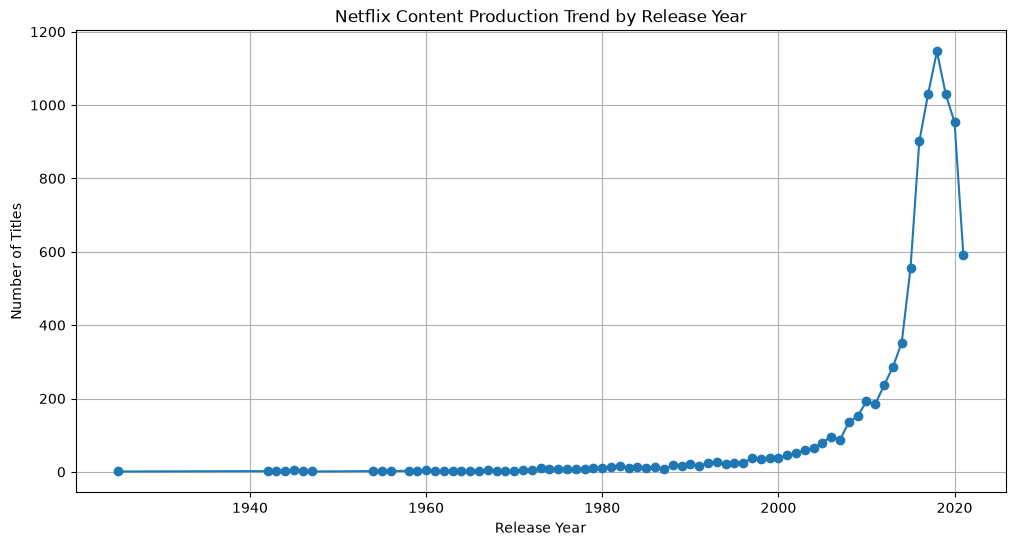

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_content['release_year'],yearly_content['Content Count'],marker='o')


plt.title("Netflix Content Production Trend by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.show()

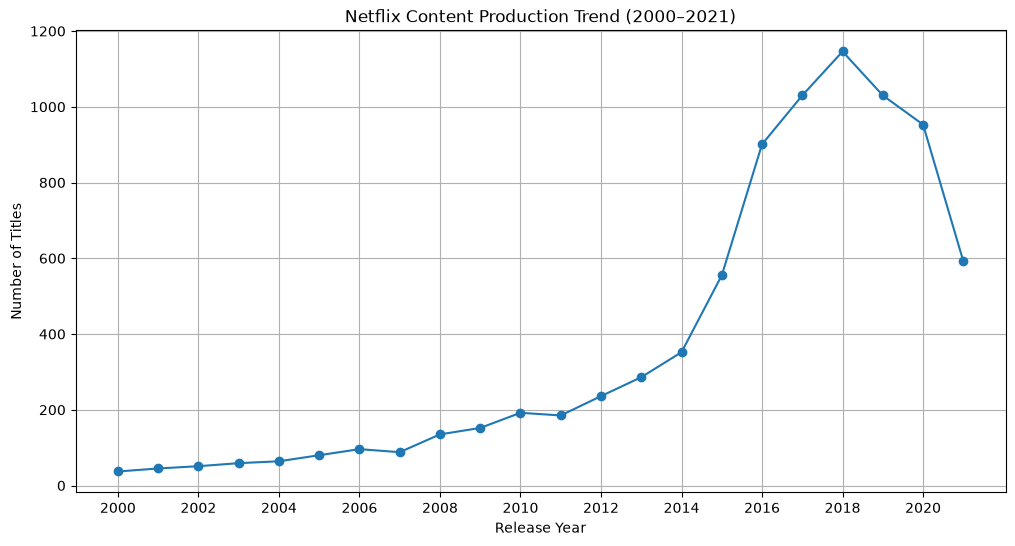

In [39]:
recent_content = yearly_content[yearly_content['release_year'] >= 2000]

plt.figure(figsize=(12, 6))

plt.plot(recent_content['release_year'],recent_content['Content Count'],marker='o')

plt.title("Netflix Content Production Trend (2000–2021)")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.xticks(range(2000, 2022, 2))

plt.grid(True)
plt.show()

<h5>This trend graph is created for recent trend visualization in the market so that we can see more clearly</h5>

<h4><b>Step 5:</b>Interpret business patterns.</h4>

<h5><b>Business insights or Key findings</b><br>
    <b>--></b>Netflix content production showed a strong upward trend, particularly from 2015 onwards.<br>
    <b>--></b>The largest year-over-year increase occurred in 2016, when content releases increased by 62.34%.<br>
    <b>--></b>Content production reached its highest level in 2018, with 1,146 titles.<br>
    <b>--></b>After 2018, the number of titles declined in 2019 and 2020, indicating a downward trend after the peak.<br>
</h5>